In [ ]:
<h1> Лабораторная работа 3</h1>

<h2>Технологии программирования </h2>

<h3> Выполнил: </h3> 
<h4> Толстых Максим Алексеевич </h4>

<h3> Группа: </h3>
<h4> НММбд-02-22 </h4>

<h2> Цель работы </h2>

Изучить распределения и моменты связанных с
преобразованием случайных величин


<h3> Задание 1 </h3>

Сгенерировали выборку точек, равномерно распределенных внутри круга (2 Радиус окружности R=10, размер выборки 1000 точек.)
двумя способами:
    
1. Равномерно распределили точки внутри квадрата, внутрь которого
вписана окружность, и отфильтровали точки, лежащие за пределами
окружности.
2. Сенерировали точки путем задания случайного угла и расстояния от
центра окружности.

<h3> Задание 2.1 </h3>

Создали рисунки, иллюстрирующие расположение точек
сгенерированных выборок №1 и №2 внутри окружности.

In [289]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [290]:
circle_radius = 10
set_size = 1000

In [291]:
# генерация первым способом
set_x = []
set_y = []
dots_counter = 0
while dots_counter < set_size:
    x = np.random.uniform(-10, 10)
    y = np.random.uniform(-10, 10)
    if x**2 + y**2 < circle_radius**2:
        set_x.append(x)
        set_y.append(y)
        dots_counter += 1

In [292]:
circle_angles=np.linspace(0, 2 * np.pi, 100)
circle_x = circle_radius * np.cos(circle_angles)
circle_y = circle_radius * np.sin(circle_angles)

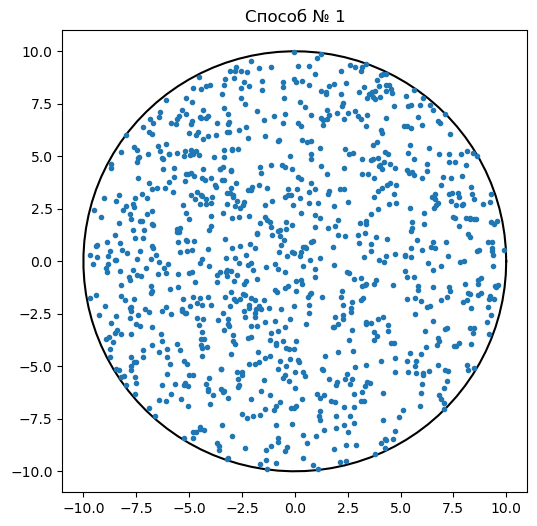

In [293]:
plt.figure(dpi=100, figsize=(6, 6))
plt.title('Способ № 1')
plt.plot(circle_x, circle_y, 'black')
plt.plot(set_x, set_y, ".")
plt.show()

In [294]:
import math

# генерация вторым способом

circle_points_x = []
circle_points_y = []

while len(circle_points_x) < set_size:
    alpha = np.random.uniform(0, 2 * math.pi)
    r = circle_radius * np.random.uniform()
    x = r * math.cos(alpha)
    y = r * math.sin(alpha)
    circle_points_x.append(x)
    circle_points_y.append(y)

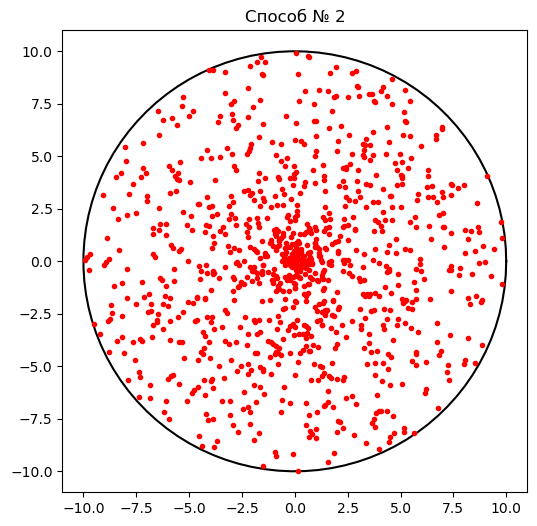

In [295]:
plt.figure(dpi=100, figsize=(6, 6))
plt.title('Способ № 2')
plt.plot(circle_x, circle_y, 'black')
plt.plot(circle_points_x, circle_points_y, "r.")
plt.show()

<h3> Задание 2.2 </h3>

Нашли выборочные средние координат точек и их дисперсию для двух способов.

In [296]:
# выборочное среднее для первого способа
print('Mean for 1 x\s', np.mean(set_x))
print('Mean for 1 y\s', np.mean(set_y))

# выборочное среднее для второго способа
print('Mean for 2 x\s', np.mean(circle_points_x))
print('Mean for 2 y\s', np.mean(circle_points_y))

Mean for 1 x\s -0.2949822087035227
Mean for 1 y\s 0.3203489067147015
Mean for 2 x\s 0.07346642986170573
Mean for 2 y\s -0.14531596327522636


In [297]:
# дисперсия для первого способа
print('Var for 1 x\s', np.var(set_x))
print('Var for 1 y\s', np.var(set_y))

# дисперсия для второго способа
print('Var for 2 x\s', np.var(circle_points_x))
print('Var for 2 y\s', np.var(circle_points_y))

Var for 1 x\s 25.02022018434497
Var for 1 y\s 23.47798388196706
Var for 2 x\s 16.341344608110898
Var for 2 y\s 16.513767379404072


<h3> Задание 2.3 </h3>

Построили график плотности распределения расстояния от случайной
равномерно распределенной точки в круге до фиксированной точки,
лежащей вне окружности(с координатами X =2 0, Y = 0). Задание выполнили для двух способов.

In [298]:
main_x = 20
main_y = 0

In [299]:
def distance(x1, y1, x2, y2):   # функция рассчёта расстояния
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [300]:
distances_1 = []
for i in range(set_size):  # создание списка расстояний до точки для первого способа
    distances_1.append(distance(set_x[i], set_y[i], main_x, main_y))
distances_1.sort()

In [301]:
distances_2 = []
for i in range(set_size):  # создание списка расстояний до точки для второго способа
    distances_2.append(distance(circle_points_x[i], circle_points_y[i], main_x, main_y))
distances_2.sort()

In [302]:
kde_distances_y_1 = gaussian_kde(distances_1).evaluate(distances_1)  # находжение плотности распределения для первого способа
kde_distances_y_2 = gaussian_kde(distances_2).evaluate(distances_2)  # находжение плотности распределения для второго способа

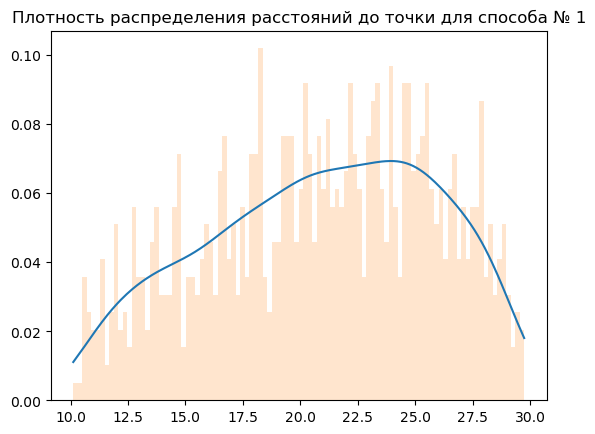

In [303]:
plt.figure(dpi=100)
plt.title('Плотность распределения расстояний до точки для способа № 1')
plt.plot(distances_1, kde_distances_y_1) # линия плотности
plt.hist(distances_1, bins=100, alpha=0.2, density=True)
plt.show()

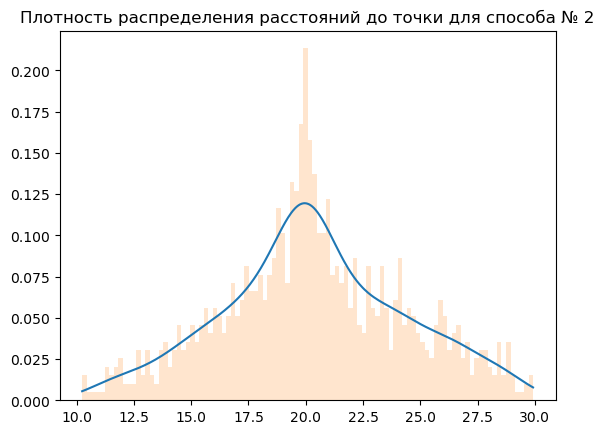

In [304]:
plt.figure(dpi=100)
plt.title('Плотность распределения расстояний до точки для способа № 2')
plt.plot(distances_2, kde_distances_y_2) # линия плотности
plt.hist(distances_2, bins=100, alpha=0.2, density=True)
plt.show()

<h3> Задание 2.4 </h3>

Построили график плотности распределения расстояния между двумя
случайными точками, равномерно расположенными внутри круга, для двух способов.

In [305]:
distances_21 = []

for _ in range(set_size): # создание списка расстояний между случайными точками для первого способа
    j = np.random.randint(0, set_size - 1)
    k = np.random.randint(0, set_size - 1)
    distances_21.append(distance(set_x[j], set_y[j], set_x[k], set_x[k]))
distances_21.sort()

In [306]:
distances_22 = []
for _ in range(set_size):  # создание списка расстояний между случайными точками для второго способа
    j = np.random.randint(0, set_size - 1)
    k = np.random.randint(0, set_size - 1)
    distances_22.append(distance(circle_points_x[j], circle_points_x[j], circle_points_y[k], circle_points_y[k]))
distances_22.sort()

In [307]:
kde_distances_y_21 = gaussian_kde(distances_21).evaluate(distances_21)  # находжение плотности распределения для первого способа
kde_distances_y_22 = gaussian_kde(distances_22).evaluate(distances_22)  # находжение плотности распределения для второго способа

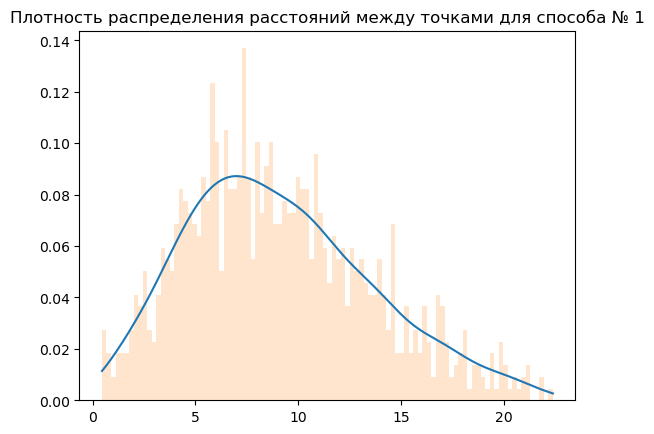

In [308]:
plt.figure(dpi=100)
plt.title('Плотность распределения расстояний между точками для способа № 1')
plt.plot(distances_21, kde_distances_y_21) # линия плотности
plt.hist(distances_21, bins=100, alpha=0.2, density=True)
plt.show()

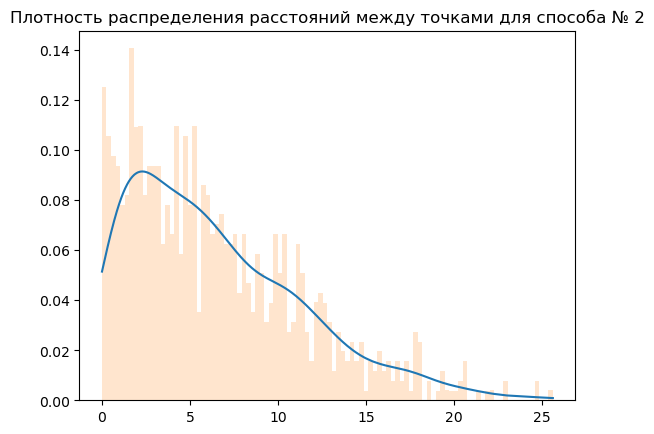

In [309]:
plt.figure(dpi=100)
plt.title('Плотность распределения расстояний между точками для способа № 2')
plt.plot(distances_22, kde_distances_y_22) # линия плотности
plt.hist(distances_22, bins=100, alpha=0.2, density=True)
plt.show()

<h3> Вывод </h3>

В ходе выполнения лабораторной работы были изучены распределения и моменты связанных с
преобразованием случайных величин.